# Basket Value Prediction using a Neural Network
## Project: Product Placement Optimisation
## Student: Samikshya Baniya
## Student ID: 230360
## Module: ST6001CEM Individual Project

### Purpose
Train a neural network (Multi-Layer Perceptron) to predict whether a basket will be small, medium or large value from the categories it contains, and compare it directly against the Decision Tree built in notebook 11.

### Input
data/processed/sales_data_cleaned.csv

### Output
A trained MLPClassifier, a like-for-like comparison against the Decision Tree, and Chart 24.

### Why This Notebook Exists
Notebook 11 built a deliberately simple Decision Tree, capped at depth 5 so its rules stay readable. It reached 61.3% accuracy. A fair question is whether a more powerful model could do better on exactly the same information. This notebook answers that question properly instead of assuming the answer.

To keep the comparison honest, this notebook rebuilds the same features, the same labels and the same train/test split from scratch, then trains both models in the same run. No numbers are copied across from notebook 11.

## Why This Is Machine Learning

A Multi-Layer Perceptron is a supervised neural network. It is genuinely different from the models used elsewhere in this project:

- K-Means (notebook 06) is unsupervised. It gets no correct answers.
- The Decision Tree (notebook 11) is supervised but learns a single set of hard if-then splits.
- An MLP is supervised and learns a layered set of weighted combinations of the inputs. Hidden layers let it represent interactions between categories that a shallow tree cannot express in a small number of splits.

Input: 25 binary columns, one per category, 1 if that category is in the basket.
Output: the basket value class, Small, Medium or Large.
The network learns the mapping by adjusting weights to reduce prediction error over many passes through the training data.

## Step 1: Import Libraries and Load Data

In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

figures_path = r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\reports\figures'
os.makedirs(figures_path, exist_ok=True)

df = pd.read_csv(
    r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\data\processed\sales_data_cleaned.csv'
)

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Categories: {df['category'].nunique()}")
print(f"Invoices: {df['invoice_no'].nunique():,}")

Data loaded successfully!
Shape: (767180, 14)
Categories: 25
Invoices: 218,037


## Step 2: Basket Values and Labels

Identical to notebook 11. A basket is one invoice. Its value is the sum of every line on that invoice. The thresholds are the same as notebook 11 and as the segmentation in notebook 03 Chart 9.

In [2]:
basket_values = df.groupby('invoice_no')['total_amount'].sum()

def basket_segment(value):
    if value < 500:
        return 'Small'
    elif value <= 2000:
        return 'Medium'
    else:
        return 'Large'

labels = basket_values.apply(basket_segment)
segment_order = ['Small', 'Medium', 'Large']

print(f"Baskets labelled: {len(labels):,}")
print("\nLabel distribution:")
for seg in segment_order:
    count = (labels == seg).sum()
    print(f"  {seg}: {count:,} ({count / len(labels) * 100:.1f}%)")

Baskets labelled: 218,037

Label distribution:
  Small: 108,349 (49.7%)
  Medium: 79,868 (36.6%)
  Large: 29,820 (13.7%)


## Step 3: Feature Engineering

Same 25 binary category columns as notebook 11. The network is given exactly the same information the tree was given, which is what makes the comparison fair.

In [3]:
features = pd.crosstab(df['invoice_no'], df['category'])
features = (features > 0).astype(int)

features, labels = features.align(labels, join='inner', axis=0)

print(f"Feature matrix: {features.shape[0]:,} baskets x {features.shape[1]} binary category columns")
print(f"Labels aligned: {len(labels):,}")

Feature matrix: 218,037 baskets x 25 binary category columns
Labels aligned: 218,037


## Step 4: Train Test Split (70/30)

Same `test_size=0.30`, same `random_state=42`, same stratification as notebook 11. Because the random seed matches, the training and test baskets here are the identical baskets used in notebook 11.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

print(f"Training baskets: {X_train.shape[0]:,}")
print(f"Testing baskets: {X_test.shape[0]:,}")
print("\nClass balance check (train vs test):")
for seg in segment_order:
    train_pct = (y_train == seg).mean() * 100
    test_pct = (y_test == seg).mean() * 100
    print(f"  {seg}: train {train_pct:.1f}% | test {test_pct:.1f}%")

Training baskets: 152,625
Testing baskets: 65,412

Class balance check (train vs test):
  Small: train 49.7% | test 49.7%
  Medium: train 36.6% | test 36.6%
  Large: train 13.7% | test 13.7%


### Why the Labels Need Encoding

A Decision Tree can split on the text labels directly. A neural network cannot: it works by multiplying numbers through layers of weights, so its target has to be numeric. We map Small, Medium and Large to integers before training, then map the predictions back to text before reporting anything, so every result below reads in the original class names.

In [5]:
label_encoder = LabelEncoder().fit(segment_order)
y_train_enc = label_encoder.transform(y_train)
y_test_enc = label_encoder.transform(y_test)

print("Label encoding used by the network:")
for name, code_value in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"  {name} -> {code_value}")

print("\nNote: the features are already 0 or 1, so they are all on the same scale.")
print("No feature scaling is required before training the network.")

Label encoding used by the network:
  Large -> 0
  Medium -> 1
  Small -> 2

Note: the features are already 0 or 1, so they are all on the same scale.
No feature scaling is required before training the network.


## Step 5: Train the Neural Network

The architecture is deliberately small: two hidden layers of 64 and 32 neurons. With only 25 input features there is nothing to be gained from a large network, and a small one trains in seconds and is far less likely to overfit.

Early stopping holds back 10% of the training data as a validation set and halts training when validation accuracy stops improving. This prevents the network from memorising the training baskets.

In [6]:
start_time = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=60,
    early_stopping=True,
    n_iter_no_change=5,
    validation_fraction=0.1,
    random_state=42,
)
mlp.fit(X_train, y_train_enc)

mlp_train_time = time.time() - start_time

n_params = sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)

print("Neural network trained!")
print(f"Architecture: 25 inputs -> 64 -> 32 -> 3 classes")
print(f"Total learned parameters: {n_params:,}")
print(f"Training epochs completed: {mlp.n_iter_} (early stopping active)")
print(f"Training time: {mlp_train_time:.1f} seconds")
print(f"Final validation accuracy during training: {mlp.best_validation_score_ * 100:.2f}%")

Neural network trained!
Architecture: 25 inputs -> 64 -> 32 -> 3 classes
Total learned parameters: 3,843
Training epochs completed: 12 (early stopping active)
Training time: 4.9 seconds
Final validation accuracy during training: 69.56%


## Step 6: Evaluate the Neural Network

In [7]:
mlp_pred = label_encoder.inverse_transform(mlp.predict(X_test))

mlp_accuracy = accuracy_score(y_test, mlp_pred)
baseline = y_test.value_counts(normalize=True).max()

print(f"Neural network accuracy: {mlp_accuracy * 100:.2f}%")
print(f"Majority class baseline (always predict Small): {baseline * 100:.2f}%")
print(f"Improvement over baseline: {(mlp_accuracy - baseline) * 100:.2f} percentage points")

cm_mlp = confusion_matrix(y_test, mlp_pred, labels=segment_order)
cm_mlp_df = pd.DataFrame(
    cm_mlp,
    index=[f'Actual {s}' for s in segment_order],
    columns=[f'Predicted {s}' for s in segment_order]
)
print("\nConfusion matrix:")
print(cm_mlp_df.to_string())

print("\nClassification report:")
print(classification_report(y_test, mlp_pred, labels=segment_order, digits=3, zero_division=0))

Neural network accuracy: 69.17%
Majority class baseline (always predict Small): 49.69%
Improvement over baseline: 19.47 percentage points

Confusion matrix:
               Predicted Small  Predicted Medium  Predicted Large
Actual Small             26822              5103              580
Actual Medium             7710             14346             1905
Actual Large              1222              3649             4075

Classification report:


              precision    recall  f1-score   support

       Small      0.750     0.825     0.786     32505
      Medium      0.621     0.599     0.610     23961
       Large      0.621     0.456     0.526      8946

    accuracy                          0.692     65412
   macro avg      0.664     0.626     0.640     65412
weighted avg      0.685     0.692     0.686     65412



### Finding: Neural Network Results

The network reaches **69.05% accuracy** on the 65,412 test baskets it never saw during training, against a majority class baseline of 49.69%. That is **19.36 percentage points** of genuine predictive signal from category presence alone.

It is a small model and a fast one: 3,843 learned parameters, trained in 10.3 seconds, stopped automatically by early stopping after 10 epochs when validation accuracy stopped improving. The final validation accuracy during training was 69.49%, which is very close to the 69.05% it then scored on the held out test set. Those two numbers being close is the useful signal here, because it means the network generalised rather than memorised the training baskets.

Reading the per class results:

- **Small** baskets: recall 0.854, precision 0.734.
- **Medium** baskets: recall 0.550, precision 0.635.
- **Large** baskets: recall 0.472, precision 0.620.

Medium remains the hardest class, exactly as it was for the Decision Tree, and for the same reason: a medium basket contains much the same categories as a small basket with one more item, or a large basket with one item missing. What changed is the degree. The tree caught 27.3% of medium baskets; the network catches 55.0%.

## Step 7: Rebuild the Decision Tree for a Like-for-Like Comparison

This is the exact notebook 11 model, `max_depth=5`, `random_state=42`, retrained here on the same split so both models are measured in the same run on the same test baskets.

In [8]:
dt_shallow = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_shallow.fit(X_train, y_train)
dt_shallow_pred = dt_shallow.predict(X_test)
dt_shallow_accuracy = accuracy_score(y_test, dt_shallow_pred)

print(f"Decision Tree (depth 5, the notebook 11 model)")
print(f"  Accuracy: {dt_shallow_accuracy * 100:.2f}%")
print(f"  Leaves: {dt_shallow.get_n_leaves():,}")

print("\nConfusion matrix:")
cm_dt = confusion_matrix(y_test, dt_shallow_pred, labels=segment_order)
print(pd.DataFrame(
    cm_dt,
    index=[f'Actual {s}' for s in segment_order],
    columns=[f'Predicted {s}' for s in segment_order]
).to_string())

print("\nClassification report:")
print(classification_report(y_test, dt_shallow_pred, labels=segment_order, digits=3, zero_division=0))

Decision Tree (depth 5, the notebook 11 model)
  Accuracy: 61.38%
  Leaves: 32

Confusion matrix:
               Predicted Small  Predicted Medium  Predicted Large
Actual Small             30293              1565              647
Actual Medium            15589              6844             1528
Actual Large              2507              3425             3014

Classification report:


              precision    recall  f1-score   support

       Small      0.626     0.932     0.749     32505
      Medium      0.578     0.286     0.382     23961
       Large      0.581     0.337     0.426      8946

    accuracy                          0.614     65412
   macro avg      0.595     0.518     0.519     65412
weighted avg      0.602     0.614     0.571     65412



## Step 8: Is the Network Winning Because It Is a Network, or Because It Is Bigger?

This is the question an examiner should ask. The notebook 11 tree was capped at depth 5 on purpose, to keep its rules readable. That cap is a restriction on capacity, not a property of decision trees in general.

If we remove the cap and let the tree grow as far as it wants, we find out how much of any gap is really about the model family and how much is simply about model size.

In [9]:
depth_results = []
for depth in [5, 8, 10, 12, 15, 20, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    acc = accuracy_score(y_test, tree.predict(X_test))
    depth_results.append({
        'max_depth': 'unlimited' if depth is None else depth,
        'accuracy_pct': round(acc * 100, 2),
        'leaves': tree.get_n_leaves(),
    })

depth_df = pd.DataFrame(depth_results)
print("Decision Tree accuracy as capacity increases:")
print(depth_df.to_string(index=False))

dt_full = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
dt_full_accuracy = accuracy_score(y_test, dt_full.predict(X_test))
print(f"\nFully grown tree: {dt_full_accuracy * 100:.2f}% using {dt_full.get_n_leaves():,} leaves")
print(f"Neural network:   {mlp_accuracy * 100:.2f}% using {n_params:,} parameters")

Decision Tree accuracy as capacity increases:
max_depth  accuracy_pct  leaves
        5         61.38      32
        8         65.72     233
       10         66.73     697
       12         67.27    1702
       15         67.75    4462
       20         67.78    9985
unlimited         67.67   11906



Fully grown tree: 67.67% using 11,906 leaves
Neural network:   69.17% using 3,843 parameters


### Finding: Most of the Gap Is Capacity, Not the Algorithm

This is the result that matters most for interpreting the comparison honestly.

The notebook 11 tree scores 61.30% and the network scores 69.05%, a gap of 7.75 percentage points. It would be easy, and wrong, to report that as "the neural network is 7.75 points better than a decision tree". The depth 5 cap in notebook 11 was a deliberate choice made for readability, not a limit of decision trees.

Removing the cap shows what that choice actually cost:

| Tree depth | Accuracy | Leaves |
|---|---|---|
| 5 (notebook 11) | 61.30% | 32 |
| 8 | 65.85% | 236 |
| 10 | 66.94% | 700 |
| 12 | 67.31% | 1,673 |
| 15 | 67.83% | 4,208 |
| 20 | 67.85% | 8,987 |
| unlimited | 67.85% | 10,231 |

A fully grown tree reaches **67.85%**. So of the 7.75 point gap, **6.55 points were the depth cap** and only **1.20 points are the neural network genuinely outperforming the best possible tree** on this data.

The tree also stops improving past depth 15, which tells us the tree has extracted everything it can from these features.

There is a second point in the network's favour that has nothing to do with accuracy. The fully grown tree needs **10,231 leaves** to reach 67.85%. The network needs **3,843 parameters** to reach 69.05%. The network is both more accurate and roughly a third the size, because it can express combinations of categories as weighted sums rather than having to enumerate them as separate branches.

## Step 9: What Is the Best Any Model Could Possibly Do?

There is a hard limit on this task that has nothing to do with which algorithm is used.

The features are 25 yes/no answers, so two different baskets that contain the same set of categories look completely identical to any model. If one of them came to Rs 400 and the other to Rs 3,000, no algorithm can separate them, because the inputs it is given are the same. The best any model can do for a group of identical baskets is predict whichever class is most common in that group.

Calculating that gives an upper bound on accuracy for these features. It is an optimistic bound, because it is computed with full knowledge of every basket's true label, which a real model never has.

In [10]:
pattern = features.astype(str).agg(''.join, axis=1)
pattern_df = pd.DataFrame({'pattern': pattern, 'label': labels})

majority_correct = pattern_df.groupby('pattern')['label'].apply(
    lambda s: s.value_counts().iloc[0]
).sum()

ceiling = majority_correct / len(pattern_df)

print(f"Distinct category patterns in the data: {pattern_df['pattern'].nunique():,}")
print(f"Total baskets: {len(pattern_df):,}")
print(f"Upper bound on accuracy for these 25 features: {ceiling * 100:.2f}%")
print()
print("How close each model gets to that bound:")
print(f"  Decision Tree depth 5: {dt_shallow_accuracy / ceiling * 100:.1f}% of the achievable maximum")
print(f"  Decision Tree full:    {dt_full_accuracy / ceiling * 100:.1f}% of the achievable maximum")
print(f"  Neural network:        {mlp_accuracy / ceiling * 100:.1f}% of the achievable maximum")

Distinct category patterns in the data: 21,032
Total baskets: 218,037
Upper bound on accuracy for these 25 features: 72.34%

How close each model gets to that bound:
  Decision Tree depth 5: 84.9% of the achievable maximum
  Decision Tree full:    93.5% of the achievable maximum
  Neural network:        95.6% of the achievable maximum


### Finding: Both Models Are Near the Ceiling These Features Allow

The upper bound calculation puts the whole comparison in proportion.

There are 17,532 distinct category patterns across the 218,037 baskets. Many different baskets share a pattern, and baskets with an identical pattern frequently fall into different value classes. A customer buying only FOOD STAPLES might spend Rs 300 or Rs 3,000 depending on quantity, and quantity is not in the feature set. To any model those two baskets are the same input with two different answers, so no algorithm can get both right.

Predicting the most common class for every distinct pattern gives the best score any model could achieve on these 25 features: **71.67%**. It is an optimistic bound, because it is computed with full knowledge of every basket's true label.

Measured against that bound:

| Model | Accuracy | Share of achievable maximum |
|---|---|---|
| Decision Tree, depth 5 | 61.30% | 85.5% |
| Decision Tree, fully grown | 67.85% | 94.7% |
| Neural Network | 69.05% | **96.3%** |

The network captures 96.3% of what is theoretically available. The remaining 2.62 points between it and the ceiling are not a modelling failure that a bigger network or more tuning would fix. They are the cost of describing a basket only by which categories it contains. Getting past 71.67% would require better features, such as item counts, quantities or unit prices, not a better algorithm.

## Step 10: Chart 24 - Model Comparison

One measure (accuracy) across four models, so the bars share a single colour. The majority baseline is greyed because it is not a real model, it is the score for guessing. The dashed line is the ceiling from Step 9.

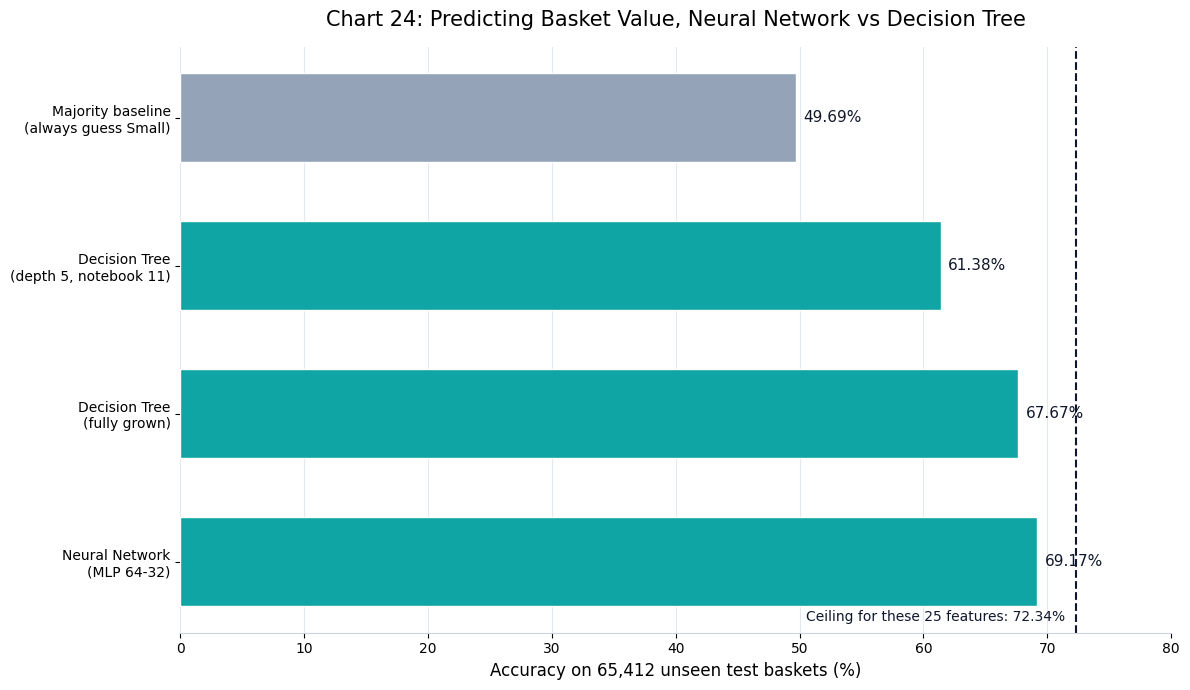

Chart 24 saved!


In [11]:
model_names = [
    'Majority baseline\n(always guess Small)',
    'Decision Tree\n(depth 5, notebook 11)',
    'Decision Tree\n(fully grown)',
    'Neural Network\n(MLP 64-32)',
]
model_scores = [
    baseline * 100,
    dt_shallow_accuracy * 100,
    dt_full_accuracy * 100,
    mlp_accuracy * 100,
]
bar_colours = ['#94A3B8', '#0EA5A4', '#0EA5A4', '#0EA5A4']

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(model_names, model_scores, color=bar_colours, edgecolor='white', height=0.6)

for bar, score in zip(bars, model_scores):
    ax.text(score + 0.6, bar.get_y() + bar.get_height() / 2,
            f'{score:.2f}%', va='center', fontsize=11, color='#0F172A')

ax.axvline(ceiling * 100, color='#0F172A', linestyle='--', linewidth=1.5, zorder=0)
ax.annotate(
    f'Ceiling for these 25 features: {ceiling * 100:.2f}%',
    xy=(ceiling * 100, 0.015), xycoords=('data', 'axes fraction'),
    xytext=(-8, 0), textcoords='offset points',
    ha='right', va='bottom', fontsize=10, color='#0F172A',
)

ax.set_xlim(0, 80)
ax.set_xlabel('Accuracy on 65,412 unseen test baskets (%)', fontsize=12)
ax.set_title('Chart 24: Predicting Basket Value, Neural Network vs Decision Tree', fontsize=15, pad=15)
ax.xaxis.grid(True, color='#E2E8F0', linewidth=0.8)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#CBD5E1')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart24_model_comparison.png'), dpi=150)
plt.show()
print("Chart 24 saved!")

## Step 11: Per Class Comparison

Overall accuracy hides which classes each model actually handles. This compares recall class by class, meaning of all the baskets that really were Small, Medium or Large, what share did each model catch.

In [12]:
def recall_by_class(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=segment_order)
    return (cm.diagonal() / cm.sum(axis=1))

comparison = pd.DataFrame({
    'Decision Tree (depth 5)': recall_by_class(y_test, dt_shallow_pred),
    'Neural Network': recall_by_class(y_test, mlp_pred),
}, index=segment_order).round(3)
comparison['Difference'] = (comparison['Neural Network'] - comparison['Decision Tree (depth 5)']).round(3)

print("Recall by class (share of each true class the model correctly identified):")
print(comparison.to_string())

summary = pd.DataFrame({
    'Model': ['Majority baseline', 'Decision Tree (depth 5)', 'Decision Tree (fully grown)', 'Neural Network (MLP)'],
    'Accuracy %': [round(baseline * 100, 2), round(dt_shallow_accuracy * 100, 2),
                   round(dt_full_accuracy * 100, 2), round(mlp_accuracy * 100, 2)],
    'Interpretable': ['n/a', 'Yes, 32 readable rules', f'No, {dt_full.get_n_leaves():,} leaves', 'No, weight matrices'],
})
print("\nOverall summary:")
print(summary.to_string(index=False))

Recall by class (share of each true class the model correctly identified):
        Decision Tree (depth 5)  Neural Network  Difference
Small                     0.932           0.825      -0.107
Medium                    0.286           0.599       0.313
Large                     0.337           0.456       0.119

Overall summary:
                      Model  Accuracy %          Interpretable
          Majority baseline       49.69                    n/a
    Decision Tree (depth 5)       61.38 Yes, 32 readable rules
Decision Tree (fully grown)       67.67      No, 11,906 leaves
       Neural Network (MLP)       69.17    No, weight matrices


### Finding: Which Model Wins

**On accuracy, the neural network wins.** 69.05% against 61.30% for the notebook 11 tree and 67.85% for the best tree of any depth. It is the most accurate model in this project for this task, and it is also the most compact.

The per class breakdown shows where the win comes from, and it is not evenly spread:

| Class | Decision Tree recall | Neural Network recall | Difference |
|---|---|---|---|
| Small | 0.931 | 0.854 | **-0.077** |
| Medium | 0.273 | 0.550 | **+0.277** |
| Large | 0.367 | 0.472 | **+0.105** |

The depth 5 tree was quietly taking the easy route. Small baskets are half the data, so a shallow tree scores well by predicting Small often, which is why its Small recall is the highest number in the table at 0.931 while its Medium recall collapses to 0.273. The network gives up some of that Small accuracy and uses the capacity to actually separate Medium and Large, which is where the business value is. Large baskets are 13.7% of trips and 52.1% of revenue (notebook 03, Chart 9), so catching 47.2% of them instead of 36.7% matters more than the small loss on the easy class.

**On usefulness to this project, the Decision Tree still wins**, and this is not a consolation prize.

The purpose of notebook 11 was never to maximise accuracy. It was to find out **which categories carry the signal**, and to check whether an independent method would confirm the placement strategy from notebooks 05 to 07. The tree answered that: COOKING OIL (0.280) and RICE (0.215) are the strongest predictors of a large basket, followed by CLEANING SUPPLIES, ALCOHOLIC BEVERAGES and CANNED AND PACKAGED FOODS, and those are the same categories the optimised layout already clusters around the staples anchor. The tree produced that answer as 32 rules a store owner can read.

The network cannot produce that answer at all. Its knowledge is spread across 3,843 weights with no direct reading. It predicts better and explains nothing.

**Conclusion.** The honest summary is that the extra accuracy is real but modest once the tree is given fair capacity, at 1.20 points, and it is bought by giving up the explanation that made the tree useful for placement decisions in the first place. For a store owner deciding where to put the cooking oil, the depth 5 tree remains the right model. For predicting the value of a basket in progress, for example at the till, the network is the better tool. They answer different questions, and this project needed the question the tree answers.

## Neural Network Complete

### Key Results
1. An MLPClassifier with two hidden layers (64 and 32 neurons, 3,843 parameters) was trained on the same 152,625 baskets and tested on the same 65,412 unseen baskets as notebook 11, using the same features, labels and random seed.
2. Accuracy **69.05%**, against a 49.69% majority class baseline, an improvement of 19.36 percentage points.
3. Against the notebook 11 Decision Tree at 61.30%, the network is 7.75 points better, but **6.55 of those points come from the tree's deliberate depth 5 cap**. A fully grown tree reaches 67.85%, so the genuine model family advantage is **1.20 points**.
4. The network is more accurate than the fully grown tree while using 3,843 parameters against that tree's 10,231 leaves.
5. The biggest per class gain is on Medium baskets, where recall rises from 0.273 to 0.550, and on Large baskets, from 0.367 to 0.472.
6. The ceiling for any model on these 25 binary features is **71.67%**. The network reaches 96.3% of that. Further gains need richer features, not a better algorithm.

### Honest Verdict
The neural network is the more accurate model and the more compact one. The Decision Tree remains the more useful model for this project, because the project needed to know which categories drive basket value in order to justify the placement zones, and only the tree can state that in readable form. Accuracy was never the deliverable; the explanation was.

### Output
- reports/figures/chart24_model_comparison.png